In [60]:
# import packages
import numpy as np
import optax
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp
from scipy.integrate import quad
import jax
import inspect
import itertools
import tqdm 

import sys, os, glob
from typing import Tuple, List

sys.path.insert(0, os.path.abspath('/home/dabin/code/EDGAR'))

# import local modules
import utils, diagnostic, loss_functions, seed_programs, hypothesis_engine

Manually edit the neuron models (Gaussian and AI) to be single peaked 

In [5]:
# BASELINE MODELS

def neuron_model_2_jax(theta, theta_pref=0.0, baseline=0.0, amplitude_1=1.0, tuning_width=1.0):
    theta_pref = jnp.clip(theta_pref, 0, 2 * jnp.pi)
    baseline = jnp.clip(baseline, 0, None)
    amplitude_1 = jnp.clip(amplitude_1, 0, None)
    tuning_width = jnp.clip(tuning_width, 0.01, None)

    theta = jnp.asarray(theta)
    theta_pref = jnp.asarray(theta_pref)    
    circ_dist_rad = lambda theta1, theta2: jnp.abs(jnp.arctan2(jnp.sin(theta1 - theta2), jnp.cos(theta1 - theta2)))
    dist_1 = circ_dist_rad(theta, theta_pref)
    return baseline + amplitude_1 * jnp.exp(-0.5 * (dist_1 / tuning_width) ** 2)   

def parameter_estimator_2(theta, spike_counts):
    """
    A parameter estimator for the double peaked neuron model. Creates a binned tuning curve from spike counts and estimates parameters using features from the tuning curve.
    Args:
        theta (np.ndarray): Input angles in radians. (n_trials,)
        spike_counts (np.ndarray): Spike counts corresponding to the angles. (n_trials,)
    Returns:
        np.ndarray: Estimated parameters [theta_pref, baseline, amplitude_1, amplitude_2_ratio, tuning_width].
    """
    n_bins = 50
    bin_idx = ((theta * n_bins) / (2 * np.pi)).astype(np.int32)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    sums = np.bincount(bin_idx, weights=spike_counts, minlength=n_bins)
    counts = np.bincount(bin_idx, minlength=n_bins)
    def gaussian_kernel(sig: int) -> np.ndarray:
        x = np.arange(-int(3 * sig), int(3 * sig) + 1)
        k = np.exp(-0.5 * (x / sig) ** 2)
        return k / np.sum(k)
    k = gaussian_kernel(2)
    pad = len(k) // 2
    sums_padded = np.pad(sums, (pad, pad), mode='wrap')
    counts_padded = np.pad(counts, (pad, pad), mode='wrap')
    num_conv = np.convolve(sums_padded, k, mode='valid')
    den_conv = np.convolve(counts_padded, k, mode='valid')
    tuning_curve = num_conv / (den_conv + 1e-8)
    pref_idx = np.argmax(tuning_curve)
    theta_pref = pref_idx * (2 * np.pi / n_bins)
    baseline = np.min(tuning_curve)
    amplitude_1 = np.max(tuning_curve) - baseline
    half_max = baseline + amplitude_1 / 2.0
    indices = (np.arange(-5, 6) + pref_idx) % n_bins
    above_half_max = tuning_curve[indices] >= half_max
    full_width_half_max = 2 * np.pi * np.sum(above_half_max) / n_bins
    tuning_width = full_width_half_max / (2.0 * np.sqrt(2 * np.log(2)))
    return np.array([theta_pref, baseline, amplitude_1, tuning_width])


In [12]:
# AI model 

def neuron_model(theta,
                theta_pref_1=0.0,
                baseline=0.0,
                amplitude_1=1.0,
                width_ccw_1=1.0,
                width_cw_1=1.0,
                exponent_1=2.0,):
    
    width_ccw_1, width_cw_1 = jnp.clip(width_ccw_1, 1e-6, None), jnp.clip(width_cw_1, 1e-6, None)
    exponent_1 = jnp.clip(exponent_1, 0.1, 5.0)    
    
    eps = 1e-12
    theta = jnp.asarray(theta)
    theta_pref_1 = jnp.asarray(theta_pref_1)

    signed_diff_1 = theta - theta_pref_1 + eps  # Add small epsilon to avoid log(0) issues
    width_1_effective = jnp.where(signed_diff_1 < 0, width_ccw_1, width_cw_1)
    width_1_effective = jnp.maximum(width_1_effective, 1e-6)
    default_peak = amplitude_1 * jnp.exp(-0.5 * (jnp.abs(signed_diff_1) / width_1_effective) ** exponent_1)

    # tile the tuning curve to the left and right, 2pi apart 
    signed_diff_left = (theta_pref_1 - 2 * jnp.pi ) - theta 
    width_effective = jnp.where(theta < theta_pref_1 - 2 * np.pi, width_ccw_1, width_cw_1)
    width_effective = jnp.maximum(width_effective, 1e-6)
    peak_left = amplitude_1 * jnp.exp(-0.5 * (jnp.abs(signed_diff_left) / width_effective) ** exponent_1)

    signed_diff_right = 2 * jnp.pi + theta_pref_1 - theta 
    width_effective = jnp.where(theta > theta_pref_1 + 2 * np.pi, width_cw_1, width_ccw_1)
    width_effective = jnp.maximum(width_effective, 1e-6)
    peak_right = amplitude_1 * jnp.exp(-0.5 * (jnp.abs(signed_diff_right) / width_effective) ** exponent_1)

    peak_1_component = default_peak + peak_right + peak_left

    return baseline + peak_1_component

def parameter_estimator(stimuli, spike_counts):
    """
    Estimates parameters for the neuron_model_v3 based on stimulus angles and observed spike counts.
    This estimator employs statistical principles to identify and characterize tuning curve peaks,
    including baseline, amplitude, asymmetric widths, preferred directions, and exponents for
    two potential peaks.

    Parameters are estimated directly from a smoothed firing rate curve, aiming for a simple
    yet robust initial estimation suitable for generalized Gaussian-like tuning profiles.

    Parameters:
    stimuli (np.ndarray): An array of stimulus angles in radians (0 to 2*pi).
    spike_counts (np.ndarray): An array of spike counts corresponding to each stimulus.

    Returns:
    np.ndarray: An array containing the estimated parameters in the following order:
                [theta_pref_1, baseline, amplitude_1, width_ccw_1, width_cw_1,
                 exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2]
    """
    # --- Configuration Constants ---
    n_bins = 180  # Number of angular bins for tuning curve estimation
    kernel_sigma = 2.5 # Sigma for Gaussian smoothing kernel
    min_peak_amplitude = 0.5 # Min amplitude (spikes/stimulus) above baseline for a peak to be considered valid
    min_model_width = 1e-6 # Minimum allowed width for numerical stability (as per model)
    default_width_value = 1.0 # Default width for non-significant peaks or non-determinable widths
    min_exponent = 0.1 # Minimum allowed exponent value
    max_exponent = 5.0 # Maximum allowed exponent value
    default_exponent_value = 2.0 # Default exponent (Gaussian)

    # --- 1. Binning and Smoothing ---
    # Convert stimuli to bin indices, handle wrap-around implicitly by modulo in bincount
    bin_idx = ((stimuli * n_bins) / (2 * np.pi)).astype(np.int32)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    sums = np.bincount(bin_idx, weights=spike_counts, minlength=n_bins)
    counts = np.bincount(bin_idx, minlength=n_bins)

    # Create Gaussian smoothing kernel
    kernel_radius = int(3 * kernel_sigma)
    x_kernel = np.arange(-kernel_radius, kernel_radius + 1)
    kernel = np.exp(-0.5 * (x_kernel / kernel_sigma) ** 2)
    kernel /= (np.sum(kernel) + 1e-8) # Normalize kernel

    # Pad arrays for circular convolution
    pad = len(kernel) // 2
    sums_padded = np.pad(sums, (pad, pad), mode='wrap')
    counts_padded = np.pad(counts, (pad, pad), mode='wrap')

    # Convolve to get smoothed sum of spikes and counts
    num_conv = np.convolve(sums_padded, kernel, mode='valid')
    den_conv = np.convolve(counts_padded, kernel, mode='valid')

    # Calculate smoothed tuning curve (avoid division by zero)
    tuning_curve = np.zeros_like(num_conv, dtype=float)
    valid_den_mask = den_conv > 1e-8
    tuning_curve[valid_den_mask] = num_conv[valid_den_mask] / den_conv[valid_den_mask]

    angle_step = 2 * np.pi / n_bins

    # --- 2. Baseline Estimation ---
    # Baseline cannot be negative
    baseline_est = np.maximum(0.0, np.min(tuning_curve))

    # --- Helper function for estimating peak shape parameters ---
    def _get_peak_params_simple(peak_idx_val, peak_idx, bsl, tc, n_bns, ang_step,
                                min_w, def_w, min_exp, max_exp, def_exp, min_amp_thresh):
        amp = peak_idx_val - bsl
        if amp < min_amp_thresh:
            return amp, def_w, def_w, def_exp # Return default parameters if amplitude too small

        # Find bins where tuning curve drops below half-max
        target_half_val = bsl + amp / 2.0
        half_ccw_bins, half_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if half_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_half_val:
                half_ccw_bins = k
            if half_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_half_val:
                half_cw_bins = k
            if half_ccw_bins > 0 and half_cw_bins > 0:
                break
        
        # Calculate width (v1-style, implicitly assuming Gaussian form for width parameter base)
        SQRT_2_LOG_2 = np.sqrt(2 * np.log(2)) 
        width_ccw = (half_ccw_bins * ang_step) / SQRT_2_LOG_2 if half_ccw_bins > 0 else def_w
        width_cw = (half_cw_bins * ang_step) / SQRT_2_LOG_2 if half_cw_bins > 0 else def_w
        
        # Clip widths to valid range
        width_ccw = np.clip(width_ccw, min_w, np.pi)
        width_cw = np.clip(width_cw, min_w, np.pi)

        # Find bins where tuning curve drops below quarter-max for exponent estimation
        target_qtr_val = bsl + amp / 4.0
        qtr_ccw_bins, qtr_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if qtr_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_qtr_val:
                qtr_ccw_bins = k
            if qtr_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_qtr_val:
                qtr_cw_bins = k
            if qtr_ccw_bins > 0 and qtr_cw_bins > 0:
                break
        
        # Exponent estimation (log(2) / log(dist_qtr / dist_half))
        exponent_estimates = []
        if half_ccw_bins > 0 and qtr_ccw_bins > half_ccw_bins: # Ensure ratio > 1 for valid log
            exponent_estimates.append(np.log(2) / np.log(qtr_ccw_bins / half_ccw_bins))
        if half_cw_bins > 0 and qtr_cw_bins > half_cw_bins:
            exponent_estimates.append(np.log(2) / np.log(qtr_cw_bins / half_cw_bins))
        
        # Take mean of valid estimates, else default
        exponent = np.mean(exponent_estimates) if exponent_estimates else def_exp
        exponent = np.clip(exponent, min_exp, max_exp)
        
        return amp, width_ccw, width_cw, exponent

    # --- 3. Peak Identification and Parameter Estimation ---
    # Find all local maxima in the smoothed tuning curve
    local_maxima = []
    for i in range(n_bins):
        prev_val = tuning_curve[(i - 1 + n_bins) % n_bins]
        next_val = tuning_curve[(i + 1) % n_bins]
        if tuning_curve[i] >= prev_val and tuning_curve[i] >= next_val:
            local_maxima.append((tuning_curve[i], i))
    local_maxima.sort(key=lambda x: x[0], reverse=True) # Sort by peak amplitude (descending)

    # Initialize all output parameters with model defaults (if no peak is found)
    theta_pref_1 = 0.0
    amplitude_1 = default_width_value # amplitude for primary peak default to 1 for non-zero contribution if peak is small
    width_ccw_1, width_cw_1, exponent_1 = default_width_value, default_width_value, default_exponent_value
    
    # Process Primary Peak
    if local_maxima:
        peak_1_val, peak_1_idx = local_maxima[0]
        # Estimate parameters for the primary (highest) peak
        amplitude_1, width_ccw_1, width_cw_1, exponent_1 = \
            _get_peak_params_simple(peak_1_val, peak_1_idx, baseline_est, tuning_curve, n_bins, angle_step,
                                    min_model_width, default_width_value, min_exponent, max_exponent,
                                    default_exponent_value, min_peak_amplitude)
        theta_pref_1 = peak_1_idx * angle_step
    
    return np.array([theta_pref_1, baseline_est, amplitude_1, width_ccw_1, width_cw_1, exponent_1,])

In [13]:
def load_ang(ang_file: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load head direction from a `.ang` file for th-1.

    The .ang file holds head orientation in radians in [0, 2π].
    Values of -1 indicate failed LED detection and are treated as invalid.

    Returns
    -------
    ang : (n_frames,) float
        Head direction with NaN for invalid frames.
    valid_mask : (n_frames,) bool
        True where orientation is valid.
    """
    ang = np.loadtxt(ang_file)
    valid_mask = ang >= 0
    ang = ang.astype(float)
    ang[~valid_mask] = np.nan
    return ang, valid_mask


def map_spikes_to_heading(
    res: np.ndarray,
    heading: np.ndarray,
    valid_mask: np.ndarray,
    fs_spike_hz: float = 20_000.0,
    behav_rate_hz: float = 39.0625,
) -> np.ndarray:
    """
    Map spike timestamps (20 kHz samples) to behaviour frames and return headings at those spikes.
    """
    samples_per_frame = fs_spike_hz / behav_rate_hz
    spike_frames = (res / samples_per_frame).astype(int)
    inside = (spike_frames >= 0) & (spike_frames < len(heading))
    spike_frames = spike_frames[inside]
    ok = valid_mask[spike_frames]
    spike_frames = spike_frames[ok]
    spike_headings = heading[spike_frames]
    return spike_headings[~np.isnan(spike_headings)]

def compute_tuning_ang_with_stats(
    clu: np.ndarray,
    res: np.ndarray,
    ang: np.ndarray,
    valid_mask: np.ndarray,
    n_bins: int = N_BINS,
    behav_rate_hz: float = 39.0625,
    ignore_labels: Tuple[int, int] = (0, 1),
):
    """
    Head-direction tuning curves for th-1 with extra stats per bin.

    Parameters
    ----------
    clu : (n_spikes,) int
        Cluster ID per spike.
    res : (n_spikes,) int
        Spike times in samples at 20 kHz.
    ang : (n_frames,) float
        Head direction in radians [0, 2π], NaN for invalid.
    valid_mask : (n_frames,) bool
        True for frames with valid tracking.
    n_bins : int
        Number of angular bins.
    behav_rate_hz : float
        Behaviour sampling rate in Hz (default ~39.0625).
    ignore_labels : tuple
        Cluster labels to ignore (default (0,1)).

    Returns
    -------
    rates : (max_label+1, n_bins) float
        Firing rates (Hz).
    spike_counts : (max_label+1, n_bins) int
        Number of spikes in each bin.
    occupancy_counts : (n_bins,) int
        Number of behaviour frames in each bin.
    occupancy_time : (n_bins,) float
        Occupancy time per bin (seconds).
    rate_std : (max_label+1, n_bins) float
        Approximate standard deviation of firing rate estimate per bin,
        assuming Poisson variability (sqrt(counts)/time).
    bin_edges : (n_bins+1,) float
        Bin edges spanning [0, 2π].
    unit_labels : list[int]
        Cluster labels kept (≥2 by default).
    """
    # Bin edges and occupancy
    bin_edges = np.linspace(0.0, 2*np.pi, n_bins + 1)
    valid_ang = ang[valid_mask]
    valid_ang = valid_ang[~np.isnan(valid_ang)]

    occupancy_counts, _ = np.histogram(valid_ang, bins=bin_edges)
    occupancy_time = occupancy_counts.astype(float) / behav_rate_hz
    occupancy_time_safe = occupancy_time.copy()
    occupancy_time_safe[occupancy_time_safe == 0] = np.inf

    # Size arrays by max cluster label
    max_label = int(clu.max()) if clu.size > 0 else -1
    spike_counts = np.zeros((max_label + 1, n_bins), dtype=int)
    rates = np.zeros_like(spike_counts, dtype=float)
    rate_std = np.zeros_like(spike_counts, dtype=float)

    present = np.unique(clu)
    unit_labels = [int(c) for c in present if c not in ignore_labels]

    for c in unit_labels:
        spike_hd = map_spikes_to_heading(res[clu == c], ang, valid_mask)
        if spike_hd.size == 0:
            continue
        counts, _ = np.histogram(spike_hd, bins=bin_edges)
        spike_counts[c, :] = counts
        rates[c, :] = counts / occupancy_time_safe
        # Approximate variance under Poisson model
        rate_std[c, :] = np.sqrt(counts) / occupancy_time_safe

    return rates, spike_counts, occupancy_counts, occupancy_time, rate_std, bin_edges, unit_labels


def load_spikes(clu_file: str, res_file: str):
    """
    Load cluster labels and spike times for a shank. (Clarified header semantics.)
    """
    clu_raw = np.loadtxt(clu_file, dtype=int)
    if clu_raw.ndim == 0:
        n_clusters_reported = int(clu_raw)
        clu = np.array([], dtype=int)
    else:
        n_clusters_reported = int(clu_raw[0])
        clu = clu_raw[1:].astype(int)

    res = np.loadtxt(res_file, dtype=int)
    if res.ndim == 0:
        res = np.array([], dtype=int)

    assert len(clu) == len(res), "clu/res length mismatch"
    return clu, res, n_clusters_reported


In [8]:
# code for selecting HD cells

from scipy.ndimage import gaussian_filter1d
from scipy.stats import circmean
from scipy.optimize import curve_fit
from scipy.stats import rayleigh

def von_mises(theta, A, mu, kappa, baseline):
    """
    Von Mises tuning curve.
    theta : radians
    A : amplitude
    mu : preferred direction (radians)
    kappa : concentration parameter
    baseline : offset
    """
    return baseline + A * np.exp(kappa * np.cos(theta - mu)) / (2*np.pi*np.i0(kappa))


def classify_hd_cells(rates, bin_edges, sigma_deg=6, alpha=0.001):
    """
    Classify head-direction cells from tuning curves.

    Parameters
    ----------
    rates : (n_cells, n_bins)
        Firing rates (Hz).
    bin_edges : (n_bins+1,)
        Bin edges in radians (0..2π).
    sigma_deg : float
        Gaussian smoothing width in degrees.
    alpha : float
        Significance threshold for Rayleigh test.

    Returns
    -------
    is_hd : (n_cells,) bool
        True if cell passes HD criteria.
    params : list of dict
        Per-cell parameters: {'mu','kappa','peak_rate','pval'}.
    smoothed : (n_cells, n_bins)
        Smoothed rate maps.
    """
    n_bins = rates.shape[1]
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    deg_per_bin = 360.0 / n_bins
    sigma_bins = sigma_deg / deg_per_bin

    # smooth
    smoothed = gaussian_filter1d(rates, sigma=sigma_bins, axis=1, mode="wrap")

    is_hd = []
    params = []

    for r in smoothed:
        # --- peak firing rate ---
        peak_rate = np.max(r)

        # --- Rayleigh test ---
        # compute mean resultant length R
        C = np.sum(r * np.cos(bin_centres))
        S = np.sum(r * np.sin(bin_centres))
        R = np.sqrt(C**2 + S**2) / np.sum(r)
        n = np.sum(r > 0)  # effective sample size proxy
        z = n * R**2
        pval = np.exp(np.sqrt(1+4*n+4*(n**2 - (n*R)**2)) - (1+2*n))
        # note: approximate Rayleigh p-value for binned firing rates

        # --- Von Mises fit ---
        try:
            mu0 = float(circmean(bin_centres, high=2*np.pi, low=0, 
                                #  weights=r
                                 ))
            p0 = [float(peak_rate), mu0, 1.0, float(np.min(r) + 0.1)]

            popt, _ = curve_fit(
                von_mises,
                bin_centres,
                r,
                p0=p0,
                bounds=([0, 0, 0, 0], [np.inf, 2*np.pi, np.inf, np.inf])
            )
            _, mu, kappa, _ = popt
        except RuntimeError:
            mu, kappa = np.nan, 0.0

        params.append({
            "mu": mu,
            "kappa": kappa,
            "peak_rate": peak_rate,
            "pval": pval,
        })

        # --- HD classification ---
        is_hd.append((kappa > 1) and (peak_rate > 1.0) and (pval < alpha))

    return np.array(is_hd), params, smoothed

In [15]:
N_BINS = int(360 / 2)
mouse_session_dict = {}

mouse = 'Mouse12' 
sessions = ['120806', '120807', '120808', '120809', '120810']
mouse_session_dict[mouse] = sessions

mouse = 'Mouse17' 
sessions = ['130125', '130128', '130129', '130130', '130131', '130201', '130202', '130203', '130204']
mouse_session_dict[mouse] = sessions

mouse = 'Mouse20' 
sessions = ['130514', '130515', '130516', '130517', '130520']
mouse_session_dict[mouse] = sessions

mouse = 'Mouse24' 
sessions = ['131213', '131216', '131217', '131218']
mouse_session_dict[mouse] = sessions

mouse = 'Mouse25' 
sessions = ['140123', '140124', '140128', '140129', '140130', '140131', '140206', '140203', '140204', '140205', '140206']
mouse_session_dict[mouse] = sessions

mouse = 'Mouse28' 
sessions = ['140310', '140311', '140312', '140313', '140317', '140318']
mouse_session_dict[mouse] = sessions

In [30]:
# ls '../../data/head_direction/AngFiles/Mouse12-120806.ang'
os.listdir()

['4_head_direction.ipynb',
 '3M_score_graphics.ipynb',
 '3M_umaps.ipynb',
 '3A_learning_curves.ipynb',
 '3B_family_trees.ipynb',
 'cvpca_experiments.ipynb',
 '1A_tuning_curves.ipynb',
 'scratchpad.ipynb',
 '2A_gradient_descent.ipynb',
 '1B_spectrum.ipynb',
 'cross_validation_tests.ipynb',
 '4A_fisher_info.ipynb']

In [32]:
BASE_DIR = '../../../data/head_direction'

population_matrices = []
units_list = []
angs_list = []
spike_counts_list = []
rates_std_list = []
occ_time_list = []

for mouse, sessions in mouse_session_dict.items():
    for session in sessions:
        print(f'Processing {mouse} session {session}')
        folder = f'{mouse}-{session}'
        base = f'{BASE_DIR}/{folder}/{folder}/'
        ang_path = f'{BASE_DIR}/AngFiles/{folder}.ang'

        if not os.path.exists(ang_path) :
            # sometimes the ang_file is stored in a different location
            ang_path = f'{BASE_DIR}/{folder}/{folder}/{folder}.ang'

        # Load head direction from .ang
        ang, valid_mask = load_ang(ang_path)
        angs_list.append(ang)

        all_rates = []
        units = []
        spike_counts_session = []
        rates_std_session = []
        occ_time_session = None

        for clu_file in sorted(glob.glob(os.path.join(base, "*.clu.*"))):
            if clu_file.endswith(".clu.0") or "Zone.Identifier" in clu_file:
                continue
            res_file = clu_file.replace(".clu.", ".res.")
            if not os.path.exists(res_file):
                continue

            clu, res, _ = load_spikes(clu_file, res_file)
            if clu.size == 0:
                continue

            (rates, spike_counts, occ_counts, occ_time,
             rate_std, edges, unit_labels) = compute_tuning_ang_with_stats(
                 clu, res, ang, valid_mask, n_bins=int(N_BINS)
             )

            real_labels = [c for c in unit_labels if c >= 2]
            if not real_labels:
                continue

            all_rates.append(rates[real_labels, :])
            basefile = os.path.basename(clu_file)
            units.extend([(basefile, int(c)) for c in real_labels])
            spike_counts_session.append(spike_counts[real_labels, :])
            rates_std_session.append(rate_std[real_labels, :])
            if occ_time_session is None:
                occ_time_session = occ_time.ravel()

        if all_rates:
            pop = np.vstack(all_rates)
            spike_counts_session = np.vstack(spike_counts_session)  # (n_cells, n_bins)
            rates_std_session = np.vstack(rates_std_session)        # (n_cells, n_bins)        

            n_cells = pop.shape[0]
            occ_time_session = np.tile(occ_time_session, (n_cells, 1))    
        else:
            pop = np.zeros((0, N_BINS), dtype=float)
            spike_counts_session = np.zeros((0, N_BINS), dtype=int)
            rates_std_session = np.zeros((0, N_BINS), dtype=float)
            occ_time_session = np.zeros(360, dtype=float)  # one vector per session

        population_matrices.append(pop)
        units_list.append(units)
        spike_counts_list.append(spike_counts_session)
        rates_std_list.append(rates_std_session)
        occ_time_list.append(occ_time_session)


Processing Mouse12 session 120806
Processing Mouse12 session 120807
Processing Mouse12 session 120808
Processing Mouse12 session 120809
Processing Mouse12 session 120810
Processing Mouse17 session 130125
Processing Mouse17 session 130128
Processing Mouse17 session 130129
Processing Mouse17 session 130130
Processing Mouse17 session 130131
Processing Mouse17 session 130201
Processing Mouse17 session 130202
Processing Mouse17 session 130203
Processing Mouse17 session 130204
Processing Mouse20 session 130514
Processing Mouse20 session 130515
Processing Mouse20 session 130516
Processing Mouse20 session 130517
Processing Mouse20 session 130520
Processing Mouse24 session 131213
Processing Mouse24 session 131216
Processing Mouse24 session 131217
Processing Mouse24 session 131218
Processing Mouse25 session 140123
Processing Mouse25 session 140124
Processing Mouse25 session 140128
Processing Mouse25 session 140129
Processing Mouse25 session 140130
Processing Mouse25 session 140131
Processing Mou

In [34]:
# stack the population matrices into a single matrix of (n_cells, edges)
response = np.vstack(population_matrices)
response_all = response.copy()

bin_centres = (edges[:-1] + edges[1:]) / 2

all_units = np.vstack(units_list)
all_spike_counts = np.vstack(spike_counts_list)
all_rates_std = np.vstack(rates_std_list)
all_occ_time = np.vstack(occ_time_list)

In [35]:
is_hd, params, smoothed = classify_hd_cells(response, edges)

print(f"{is_hd.sum()} / {len(is_hd)} classified as HD cells")

response_parsed  = response[is_hd]
all_units_parsed = all_units[is_hd]
all_rates_std_parsed = all_rates_std[is_hd]
all_occ_time_parsed = all_occ_time[is_hd]
all_spike_counts_parsed = all_spike_counts[is_hd]

response_parsed /= np.maximum(np.linalg.norm(response_parsed, axis=1, keepdims=True), 1e-12)
bin_centers_extended = np.repeat(bin_centres[np.newaxis, :], response_parsed.shape[0], axis=0)

423 / 1535 classified as HD cells


Cross-validated fit : Train on train angles and evaluate and test angles

In [36]:
# just use train, test split - 75% of trials as train, 25% as test
rng = np.random.default_rng(seed=42)

train_size = int(0.45 * response_parsed.shape[1])
val_size = int(0.3 * response_parsed.shape[1])
# First split: train set
train_trials = rng.choice(N_BINS, size=train_size, replace=False)
val_trials = rng.choice(np.setdiff1d(np.arange(N_BINS), train_trials), size=val_size, replace=False)
test_trials = np.setdiff1d(np.arange(N_BINS), np.concatenate([train_trials, val_trials]))

train_response, train_angles = response_parsed[:, train_trials], bin_centers_extended[:, train_trials]
val_response, val_angles = response_parsed[:, val_trials], bin_centers_extended[:, val_trials]
test_response, test_angles   = response_parsed[:, test_trials], bin_centers_extended[:, test_trials]
train_val_response = jnp.concatenate([train_response, val_response], axis=1)
train_val_angles = jnp.concatenate([train_angles, val_angles], axis=1)

In [ ]:
SEED = 42
ai_results_cv = utils.train_with_patience_optimization(
    # x_data=[train_angles, val_angles, test_angles, train_val_angles],
    # y_data=[train_response, val_response, test_response, train_val_response],
    x_data = train_val_angles,
    y_data = train_val_response,
    val1_fraction = 0.4,    
    neuron_model=neuron_model,
    parameter_estimator=parameter_estimator,
    learning_rate=1e-3,
    num_steps=8_000,
    loss_function=loss_functions.quadratic_loss,
    seed=SEED,
    )

gaussian_results_cv = utils.train_with_patience_optimization(
    # x_data=[train_angles, val_angles, test_angles, train_val_angles],
    # y_data=[train_response, val_response, test_response, train_val_response],
    x_data = train_val_angles,
    y_data = train_val_response,
    val1_fraction = 0.4,    
    neuron_model=neuron_model_2_jax,
    parameter_estimator=parameter_estimator_2,
    learning_rate=1e-3,
    num_steps=8_000,
    loss_function=loss_functions.quadratic_loss,
    seed=SEED,
    )

Data split: 81 train, 54 val1, 0 val2

=== Phase A: Train on TRAIN only ===

Step  100 | Train mean: 0.0014 | Val1 mean: 0.0015
Step  200 | Train mean: 0.0012 | Val1 mean: 0.0013
Step  300 | Train mean: 0.0010 | Val1 mean: 0.0012
Step  400 | Train mean: 0.0009 | Val1 mean: 0.0011
Step  500 | Train mean: 0.0008 | Val1 mean: 0.0010
Step  600 | Train mean: 0.0007 | Val1 mean: 0.0009
Step  700 | Train mean: 0.0007 | Val1 mean: 0.0008
Step  800 | Train mean: 0.0006 | Val1 mean: 0.0007
Step  900 | Train mean: 0.0005 | Val1 mean: 0.0006
Step 1000 | Train mean: 0.0005 | Val1 mean: 0.0006
Step 1100 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1200 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1300 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1400 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1500 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1600 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1700 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1800 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 

In [44]:
def make_explained_var_score_on_means(model):
    def _score(params, angles, response):  # responses: (n_cells, n_stims)
        preds = jax.vmap(lambda p, a: model(a, *p), in_axes=(0, 0))(params, angles)  # (n_cells, n_stims)
        ss_res = jnp.sum((response - preds) ** 2, axis=1) # (n_cells,)
        ss_tot = jnp.sum((response - response.mean(axis=1, keepdims=True)) ** 2, axis=1) # (n_cells,)
        return 1.0 - (ss_res / (ss_tot + 1e-12))
    return jax.jit(_score)

explained_var_ai = make_explained_var_score_on_means(neuron_model)
explained_var_gaussian = make_explained_var_score_on_means(neuron_model_2_jax)

mean_ai_explained_var_cv = explained_var_ai(ai_results_cv['params'], test_angles, test_response)
mean_gaussian_explained_var_cv = explained_var_gaussian(gaussian_results_cv['params'], test_angles, test_response)

In [45]:
# smooth the data and check the number of peaks. Create a filter that only allows cells with one peak.
from scipy.signal import find_peaks
smoothed_response = gaussian_filter1d(np.asarray(response_parsed), sigma=25, axis=1, mode='wrap')
num_peaks = np.array([len(find_peaks(smoothed_response[i])[0]) for i in range(smoothed_response.shape[0])])
print(f"Number of cells with one peak: {(num_peaks == 1).sum()} / {num_peaks.shape[0]}")

one_peak_mask = (num_peaks == 1)

Number of cells with one peak: 388 / 423


In [46]:
mouse12_cells_mask = np.asarray([(u[0].startswith('Mouse12')) for u in all_units], dtype=bool)
mouse17_cells_mask = np.asarray([(u[0].startswith('Mouse17')) for u in all_units], dtype=bool)
mouse20_cells_mask = np.asarray([(u[0].startswith('Mouse20')) for u in all_units], dtype=bool)
mouse24_cells_mask = np.asarray([(u[0].startswith('Mouse24')) for u in all_units], dtype=bool)
mouse25_cells_mask = np.asarray([(u[0].startswith('Mouse25')) for u in all_units], dtype=bool)
mouse28_cells_mask = np.asarray([(u[0].startswith('Mouse28')) for u in all_units], dtype=bool)

is_hd = np.asarray(is_hd, dtype=bool)
hd_indices = np.where(is_hd)[0]

# Find which HD cells are from mouse 12
hd_and_one_peak_mouse12_mask = mouse12_cells_mask[hd_indices][one_peak_mask]  # shape (314,)
hd_and_one_peak_mouse17_mask = mouse17_cells_mask[hd_indices][one_peak_mask]  # shape (314,)
hd_and_one_peak_mouse20_mask = mouse20_cells_mask[hd_indices][one_peak_mask]  # shape (314,)
hd_and_one_peak_mouse24_mask = mouse24_cells_mask[hd_indices][one_peak_mask]  # shape (314,)
hd_and_one_peak_mouse25_mask = mouse25_cells_mask[hd_indices][one_peak_mask]  # shape (314,)
hd_and_one_peak_mouse28_mask = mouse28_cells_mask[hd_indices][one_peak_mask]  # shape (314,)

one_peak_per_mouse_count = [
    np.sum(hd_and_one_peak_mouse12_mask),
    np.sum(hd_and_one_peak_mouse17_mask),
    np.sum(hd_and_one_peak_mouse20_mask),
    np.sum(hd_and_one_peak_mouse24_mask),
    np.sum(hd_and_one_peak_mouse25_mask),
    np.sum(hd_and_one_peak_mouse28_mask)
]

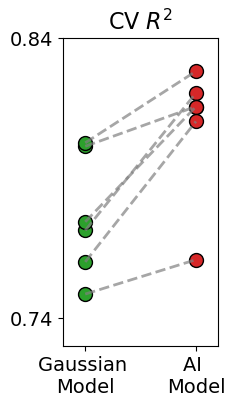

In [48]:
mouse_groups = {
    'Mouse12': mouse12_cells_mask,
    'Mouse17': mouse17_cells_mask,
    'Mouse20': mouse20_cells_mask,
    'Mouse24': mouse24_cells_mask,
    'Mouse25': mouse25_cells_mask,
    'Mouse28': mouse28_cells_mask,
}

mask = one_peak_mask 

fig, ax = plt.subplots(figsize=(2, 4))
for mouse, mouse_mask in mouse_groups.items():
    combined_mask = mouse_mask[hd_indices] & mask
    if np.sum(combined_mask) == 0:
        continue
    avg_gaussian_ev = jnp.mean(mean_gaussian_explained_var_cv[combined_mask])
    avg_ai_ev = jnp.mean(mean_ai_explained_var_cv[combined_mask])    

    plt.plot([0, 1], [avg_gaussian_ev, avg_ai_ev], linewidth=2, linestyle='--', c='gray', alpha=0.7
        # label=f'{mouse} N={np.sum(combined_mask)}'
    )
    marker_colors = ['tab:green', 'tab:red']
    for x, y, color in zip([0, 1], [avg_gaussian_ev, avg_ai_ev], marker_colors):
        plt.scatter(x, y, color=color, alpha=1.0, s=100, edgecolor='black', marker='o',)    

plt.xticks([0, 1], ['Gaussian \nModel', 'AI \nModel'], fontsize=14)
plt.yticks([0.74, 0.84], fontsize=14)
plt.xlim(-0.2, 1.2)
plt.ylim(0.73, 0.84)
plt.title(rf'CV $R^2$', fontsize=16)
plt.show()

Train on all angles

In [ ]:
ai_results = utils.train_with_patience_optimization(
    # x_data=[train_angles, val_angles, test_angles, train_val_angles, bin_centers_extended],
    # y_data=[train_response, val_response, test_response, train_val_response, response_parsed],
    x_data=bin_centers_extended,
    y_data=response_parsed,
    neuron_model=neuron_model,
    parameter_estimator=parameter_estimator,
    learning_rate=1e-3,
    num_steps=8_000,
    loss_function=loss_functions.quadratic_loss,
    val1_fraction=0.3,
    seed=SEED,
    )

gaussian_results = utils.train_with_patience_optimization(
    # x_data=[train_angles, val_angles, test_angles, train_val_angles, bin_centers_extended],
    # y_data=[train_response, val_response, test_response, train_val_response, response_parsed],
    x_data=bin_centers_extended,
    y_data=response_parsed,
    neuron_model=neuron_model_2_jax,
    parameter_estimator=parameter_estimator_2,
    learning_rate=1e-3,
    num_steps=8_000,
    loss_function=loss_functions.quadratic_loss,
    val1_fraction=0.3,
    seed=SEED,
    )

Data split: 126 train, 54 val1, 0 val2

=== Phase A: Train on TRAIN only ===

Step  100 | Train mean: 0.0014 | Val1 mean: 0.0014
Step  200 | Train mean: 0.0012 | Val1 mean: 0.0012
Step  300 | Train mean: 0.0011 | Val1 mean: 0.0011
Step  400 | Train mean: 0.0010 | Val1 mean: 0.0010
Step  500 | Train mean: 0.0009 | Val1 mean: 0.0009
Step  600 | Train mean: 0.0008 | Val1 mean: 0.0008
Step  700 | Train mean: 0.0007 | Val1 mean: 0.0007
Step  800 | Train mean: 0.0006 | Val1 mean: 0.0007
Step  900 | Train mean: 0.0005 | Val1 mean: 0.0006
Step 1000 | Train mean: 0.0005 | Val1 mean: 0.0006
Step 1100 | Train mean: 0.0005 | Val1 mean: 0.0005
Step 1200 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1300 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1400 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1500 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1600 | Train mean: 0.0004 | Val1 mean: 0.0005
Step 1700 | Train mean: 0.0004 | Val1 mean: 0.0004
Step 1800 | Train mean: 0.0004 | Val1 mean: 0.0004
Step

Text(0.5, 1.0, 'Distribution of Peakiness Parameter Across Cells')

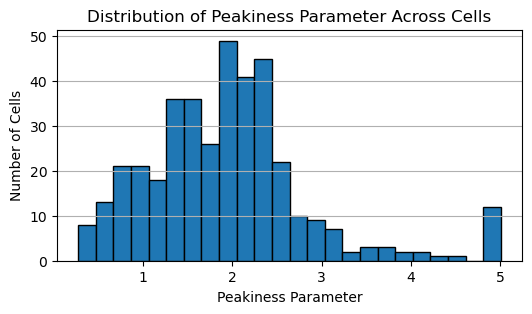

In [53]:
ai_params = ai_results['params']
gaussian_params = gaussian_results['params']

# show distribution of exponent parameter 
plt.figure(figsize=(6,3))
mask = one_peak_mask
plt.hist(ai_params[mask, -1], bins=24, edgecolor='black', color='tab:blue')
plt.xlabel('Peakiness Parameter')
plt.ylabel('Number of Cells')
plt.grid(axis='y')
plt.title('Distribution of Peakiness Parameter Across Cells')

cvPCA

In [54]:
def map_spikes_to_heading_random(res, clu_mask, ang, valid_mask, frame_mask,
                                 fs_spike_hz=20_000.0, behav_rate_hz=39.0625):
    """
    Map spikes for one unit into train/val sets using a random frame split.
    
    Parameters
    ----------
    res : (n_spikes,) int
        Spike times in samples (20 kHz).
    clu_mask : (n_spikes,) bool
        Boolean mask selecting spikes from this unit.
    ang : (n_frames,) float
        Head direction (radians, NaN for invalid).
    valid_mask : (n_frames,) bool
        Boolean mask for valid tracking.
    frame_mask : (n_frames,) bool
        Boolean mask defining the training frames; complement is validation.
    
    Returns
    -------
    hd_train, hd_val : arrays of spike angles (radians).
    """
    samples_per_frame = fs_spike_hz / behav_rate_hz
    spike_frames = (res[clu_mask] / samples_per_frame).astype(int)

    inside = (spike_frames >= 0) & (spike_frames < len(ang))
    spike_frames = spike_frames[inside]

    valid = valid_mask[spike_frames]
    spike_frames = spike_frames[valid]

    spike_hd = ang[spike_frames]
    spike_hd = spike_hd[~np.isnan(spike_hd)]

    hd_train = spike_hd[frame_mask[spike_frames]]
    hd_val   = spike_hd[~frame_mask[spike_frames]]
    return hd_train, hd_val

def compute_tuning_ang_blocksplit(clu, res, ang, valid_mask,
                                  n_bins=60, behav_rate_hz=39.0625,
                                  ignore_labels=(0,1), n_splits=2,
                                  randomise_blocks=False,
                                  block_size=40,
                                  return_velocity=False,
                                  ):
    """
    Compute tuning curves by splitting data into n_splits groups of 10-frame blocks.
    After each 10-frame block, skip 1 frame before continuing.
    Blocks are randomly assigned to groups.

    Parameters
    ----------
    clu : array of int
        Cluster IDs for spikes.
    res : array of int
        Spike times in samples at 20 kHz.
    ang : array of float
        Head direction in radians [0, 2π], NaN for invalid.
    valid_mask : array of bool
        True for valid tracking frames.
    n_bins : int
        Number of angular bins.
    behav_rate_hz : float
        Behaviour sampling rate (~39.0625 Hz).
    ignore_labels : tuple
        Cluster labels to ignore (default: (0,1)).
    n_splits : int
        Number of groups to split blocks into.
    randomise_blocks : bool
        If True, randomly assign 10-frame blocks; otherwise split contiguously.
    block_size : int
        Number of frames per block (default 40).
    return_velocity : bool
        If True, also return angular velocity (rad/s).

    Returns
    -------
    rates_groups : list of arrays
        Each entry is (n_cells, n_bins) firing rates for that group.
    bin_edges : (n_bins+1,) float
        Angular bin edges.
    unit_labels : list[int]
        Labels of units kept.
    velocity : array of float, optional
        Instantaneous angular velocity (rad/s), if return_velocity=True.
    """

    seed = 100
    rng = np.random.default_rng(seed)
    bin_edges = np.linspace(0, 2*np.pi, n_bins+1)

    valid_indices = np.where(valid_mask & ~np.isnan(ang))[0]

    if randomise_blocks:
        # Partition valid indices into 10-frame blocks, skipping 1 frame after each block
        skip = 4 # ~10 seconds (40 / 39.0625 Hz), skip ~1 second (4 / 39.0625 Hz)
        blocks = []
        i = 0
        while i + block_size <= len(valid_indices):
            block = valid_indices[i:i+block_size]
            blocks.append(block)
            i += block_size + skip

        n_blocks = len(blocks)
        if n_blocks == 0:
            return [np.zeros((0, n_bins)) for _ in range(n_splits)], bin_edges, []

        # Randomly assign blocks to groups
        idx = np.arange(n_blocks)
        rng.shuffle(idx)
        groups = np.array_split(idx, n_splits)

        # Build frame masks for each group
        frame_masks = [np.zeros_like(ang, dtype=bool) for _ in range(n_splits)]
        for g, group_idx in enumerate(groups):
            for b in group_idx:
                frame_masks[g][blocks[b]] = True

    else:
        # just split the session into n_splits contiguous segments
        skip_gap = 4 
        num_skips = n_splits - 1
        n_frames = len(valid_indices)

        segment_size = (n_frames - (num_skips * skip_gap)) // n_splits
        frame_masks = [np.zeros_like(ang, dtype=bool) for _ in range(n_splits)]
        i_start = 0 
        for g in range(n_splits):
            i_end = i_start + segment_size
            if g == n_splits - 1 :
                i_end = n_frames 
            segment_idx = valid_indices[i_start:i_end]  
            frame_masks[g][segment_idx] = True
            i_start = i_end + skip_gap  # skip 10 frames between segments
        # groups = [valid_indices[i*segment_size:(i+1)*segment_size] if i < n_splits - 1 else valid_indices[i*segment_size:] for i in range(n_splits)]

    # Occupancy for each group
    occ_times = []
    for g in range(n_splits):
        occ_counts, _ = np.histogram(ang[frame_masks[g]], bins=bin_edges)
        occ_time = occ_counts / behav_rate_hz
        occ_time[occ_time == 0] = np.inf
        occ_times.append(occ_time)


    # Allocate rates per group
    max_label = int(clu.max()) if clu.size > 0 else -1
    rates_groups = [np.zeros((max_label+1, n_bins)) for _ in range(n_splits)]
    unit_labels = []

    # --- Precompute velocity once ---
    if return_velocity:
        # dtheta = np.diff(np.unwrap(ang))
        # vel_full = np.concatenate([[0], dtheta * behav_rate_hz])
        vel_full = np.zeros_like(ang)
        valid = valid_mask & ~np.isnan(ang)
        ang_valid = np.unwrap(ang[valid])
        dtheta = np.diff(ang_valid)
        vel_segment = np.concatenate([[0], dtheta * behav_rate_hz])
        vel_full[valid] = vel_segment

        vel_groups = []
        for g in range(n_splits):
            # mask = frame_masks[g] & ~np.isnan(ang)
            mask = frame_masks[g] & valid_mask & ~np.isnan(ang)
            # print(f"g={g}, mask sum={mask.sum()}, ang range={np.nanmin(ang[mask]):.2f}–{np.nanmax(ang[mask]):.2f}")
            vel_bin_means, _ = np.histogram(
                ang[mask],
                bins=bin_edges,
                weights=vel_full[mask]
            )
            counts, _ = np.histogram(ang[mask], bins=bin_edges)
            with np.errstate(divide='ignore', invalid='ignore'):
                vel_bin_means = np.divide(
                    vel_bin_means, counts,
                    out=np.zeros_like(vel_bin_means),
                    where=counts > 0
                )
            vel_bin_means[counts == 0] = 0
            vel_groups.append(vel_bin_means)

    for c in np.unique(clu):
        if c in ignore_labels:
            continue
        # Map spikes into each group
        for g in range(n_splits):
            hd_group, _ = map_spikes_to_heading_random(
                res, clu == c, ang, valid_mask, frame_masks[g]
            )
            counts, _ = np.histogram(hd_group, bins=bin_edges)
            rates_groups[g][c] = counts / occ_times[g]
        unit_labels.append(int(c))

    if randomise_blocks:
        print(f"Number of blocks: {n_blocks}")

    # --- Velocity calculation ---
    if return_velocity:
        return rates_groups, bin_edges, unit_labels, vel_groups
    else:
        return rates_groups, bin_edges, unit_labels
    
def crossval_population_matrices_blocksplit(base, ang_file,
                                            n_bins=N_BINS, n_splits=3,
                                            behav_rate_hz=39.06,
                                            randomise_blocks=False,
                                            block_size=40, 
                                            return_velocity=False,
                                            ):
    """
    Build cross-validated population matrices using block-based splitting.

    Parameters
    ----------
    base : str
        Directory containing `.clu.N` and `.res.N` files.
    ang_file : str
        Path to `.ang` file for head direction.
    n_bins : int
        Number of angular bins.
    n_splits : int
        Number of groups to split blocks into (e.g. 3 for train/val/test).
    behav_rate_hz : float
        Behaviour sampling rate (default 39.06 Hz).

    Returns
    -------
    population_groups : list of arrays
        Each entry is (n_cells, n_bins) firing rates for one split.
    units : list of (filename, cluster_label)
        Labels of units kept (same order as rows in population_groups[g]).
    bin_edges : (n_bins+1,) float
        Angular bin edges.
    """
    ang, valid_mask = load_ang(ang_file)

    all_rates_per_group = [[] for _ in range(n_splits)]
    all_vel_per_group = [[] for _ in range(n_splits)] if return_velocity else None
    units = []
    bin_edges = None

    for clu_file in sorted(glob.glob(os.path.join(base, "*.clu.*"))):
        if clu_file.endswith(".clu.0") or "Zone.Identifier" in clu_file:
            continue
        res_file = clu_file.replace(".clu.", ".res.")
        if not os.path.exists(res_file):
            continue

        clu, res, _ = load_spikes(clu_file, res_file)
        if clu.size == 0:
            continue

        if return_velocity:
            rates_groups, edges, unit_labels, vel_groups = compute_tuning_ang_blocksplit(
                clu, res, ang, valid_mask,
                n_bins=n_bins, behav_rate_hz=behav_rate_hz,
                n_splits=n_splits, randomise_blocks=randomise_blocks,
                block_size=block_size,
                return_velocity=True,
                )
            # if raise an error if the vel_groups is all nans 
            for g in range(n_splits):
                if np.all(np.isnan(vel_groups[g])):
                    raise ValueError(f"All NaN velocity for group {g} in file {clu_file}")
        else:
            rates_groups, edges, unit_labels = compute_tuning_ang_blocksplit(
                clu, res, ang, valid_mask,
                n_bins=n_bins, behav_rate_hz=behav_rate_hz,
                n_splits=n_splits, randomise_blocks=randomise_blocks,
                block_size=block_size
            )
        real_labels = [c for c in unit_labels if c >= 2]
        if not real_labels:
            continue

        for g in range(n_splits):
            all_rates_per_group[g].append(rates_groups[g][real_labels, :])
            if return_velocity:
                all_vel_per_group[g].append(np.tile(vel_groups[g], (len(real_labels), 1)))

        basefile = os.path.basename(clu_file)
        units.extend([(basefile, int(c)) for c in real_labels])

        bin_edges = edges

    # Stack across shanks → full population
    population_groups = []
    velocity_groups = [] if return_velocity else None
    for g in range(n_splits):
        if all_rates_per_group[g]:
            pop = np.vstack(all_rates_per_group[g])
        else:
            pop = np.zeros((0, n_bins))
        population_groups.append(pop)

        if return_velocity:
            if all_vel_per_group[g]:
                vel = np.vstack(all_vel_per_group[g])
            else:
                vel = np.zeros((0, n_bins))
            velocity_groups.append(vel)

    if return_velocity:
        return population_groups, units, bin_edges, velocity_groups
    else:
        return population_groups, units, bin_edges

In [56]:
n_cells, n_stims = response.shape
n_splits = 6
R = np.zeros((n_splits, n_cells, n_stims))
V = np.zeros((n_splits, n_cells, n_stims))  # velocity matrices
units_all = np.zeros((n_cells, 2), dtype=object)  # (clu_file, cluster_label)
return_velocity = False

BASE_DIR = '../../../data/head_direction/'

n_cells_so_far = 0
for mouse, sessions in mouse_session_dict.items():
    for session in sessions:
        print(f'Processing {mouse} session {session}')
        folder = f'{mouse}-{session}'
        base = f'{BASE_DIR}{folder}/{folder}/'
        ang_path = f'{BASE_DIR}AngFiles/{folder}.ang'

        if not os.path.exists(ang_path):
            ang_path = f'{BASE_DIR}{folder}/{folder}/{folder}.ang'

        if return_velocity:
            r_list, units, edges, vel = crossval_population_matrices_blocksplit(
                base=base,
                ang_file=ang_path,
                n_bins=N_BINS,
                n_splits=n_splits, 
                randomise_blocks=True,
                block_size=12_000,
                return_velocity=return_velocity,
            )
        else:
            r_list, units, edges = crossval_population_matrices_blocksplit(
                base=base,
                ang_file=ang_path,
                n_bins=N_BINS,
                n_splits=n_splits, 
                randomise_blocks=True,
                block_size=12_000,
                return_velocity=return_velocity,
            )

        n_cells_session = r_list[0].shape[0]

        for i in range(n_splits):
            R[i, n_cells_so_far:n_cells_so_far + n_cells_session, :] = r_list[i]
            if return_velocity:
                V[i, n_cells_so_far:n_cells_so_far + n_cells_session, :] = vel[i]

        units_all[n_cells_so_far:n_cells_so_far + n_cells_session, :] = units
        n_cells_so_far += n_cells_session


Processing Mouse12 session 120806
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Number of blocks: 66
Processing Mouse12 session 120807
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Number of blocks: 62
Processing Mouse12 session 120808
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Number of blocks: 72
Processing Mouse12 session 120809
Number of blocks: 56
Number of blocks: 56
Num

In [62]:
# --- Parameters ---
bandwidth_min, bandwidth_max = np.pi / 64, np.pi / 6
window_size = 100
tol = 1e-4          # stop when search interval is small
max_iter = 5        # number of binary search iterations

R_parsed = R[:, is_hd, :]
angles_padded = np.concatenate([bin_centres - 2*np.pi, bin_centres, bin_centres + 2*np.pi])
R_padded = np.concatenate([R_parsed, R_parsed, R_parsed], axis=2)
angles_padded = angles_padded[len(bin_centres)-window_size : 2*len(bin_centres)+window_size]
R_padded = R_padded[:, :, len(bin_centres)-window_size : 2*len(bin_centres)+window_size]

n_cells = R_parsed.shape[1]

def gaussian_smooth(R, theta, bandwidth_rad=np.pi/8):
    """
    Smooth responses for all cells using a Gaussian kernel.

    Parameters
    ----------
    R : (n_cells, n_trials)
        Response matrix.
    theta : (n_trials,)
        Angles (radians).
    bandwidth_rad : float
        Standard deviation of Gaussian kernel in radians.

    Returns
    -------
    R_smooth : (n_cells, n_trials)
        Smoothed predictions for each cell.
    """
    # Precompute Gaussian kernel
    circ_dist = lambda x, y: np.minimum(np.abs(x - y), 2 * np.pi - np.abs(x - y))
    angle_diffs = circ_dist(theta[None, :], theta[:, None])  # (n_trials, n_trials)
    kernel = np.exp(-0.5 * (angle_diffs / bandwidth_rad) ** 2)
    kernel /= kernel.sum(axis=1, keepdims=True)  # normalize

    # Perform smoothing using matrix multiplication
    R_smooth = kernel @ R.T
    R_smooth = R_smooth.T  # Transpose back to original shape (n_cells, n_trials)

    return R_smooth

# --- Helper: compute cross-validated MSE across distinct sessions ---
def evaluate_bandwidth(bandwidth_rad):
    """Smooth all repeats with given frac and compute mean cross-validated MSE."""
    R_smooth_tmp = np.zeros_like(R_parsed)

    # Smooth all repeats
    for session in range(n_splits):
        preds_padded = gaussian_smooth(
            R=R_padded[session],
            theta=angles_padded,
            bandwidth_rad=bandwidth_rad,
        )
        R_smooth_tmp[session] = preds_padded[:, window_size:-window_size]

    # Cross-validated MAE across distinct session pairs
    mae_vals = []
    for c in range(n_cells):
        for i in range(n_splits):
            for j in range(n_splits):
                if i == j:
                    continue  # distinct sessions only
                diff = R_smooth_tmp[i, c, :] - R_parsed[j, c, :]
                mae_vals.append(np.nanmean(np.abs(diff)))
    return np.nanmean(mae_vals)


# --- Binary search for MAE minimum ---
low, high = bandwidth_min, bandwidth_max
best_bandwidth, best_mae = None, np.inf

for it in range(max_iter):
    mid = (low + high) / 2
    delta = (high - low) / 4  # small perturbation for left/right comparisons

    left_bandwidth = max(bandwidth_min, mid - delta)
    right_bandwidth = min(bandwidth_max, mid + delta)

    mae_left = evaluate_bandwidth(left_bandwidth)
    mae_right = evaluate_bandwidth(right_bandwidth)
    print(f"Iter {it+1}: left={left_bandwidth:.4f} MAE={mae_left:.6f}, right={right_bandwidth:.4f} MAE={mae_right:.6f}")

    # Move toward side with lower MAE
    if mae_left < mae_right:
        high = mid
        best_bandwidth, best_mae = left_bandwidth, mae_left
    else:
        low = mid
        best_bandwidth, best_mae = right_bandwidth, mae_right

    if abs(high - low) < tol:
        break

print(f"\nBest bandwidth ≈ {best_bandwidth:.4f} (mean cross-val MAE={best_mae:.6f})")


# --- Final smoothing with best bandwidth ---
R_smooth = np.zeros_like(R_parsed)
for session in tqdm.tqdm(range(n_splits), desc=f"Final smoothing (bandwidth={best_bandwidth:.4f})"):
    preds_padded = gaussian_smooth(
        R=R_padded[session],
        theta=angles_padded,
        bandwidth_rad=best_bandwidth,
    )
    R_smooth[session] = preds_padded[:, window_size:-window_size]

# --- Final cross-validated MAE (for reporting) ---
mae_vals = []
for c in range(n_cells):
    for i in range(n_splits):
        for j in range(n_splits):
            if i == j:
                continue
            diff = R_smooth[i, c, :] - R_parsed[j, c, :]
            mae_vals.append(np.nanmean(np.abs(diff)))
mae_vals = np.array(mae_vals)

print(f"\nFinal cross-validated MAE (best bandwidth): {mae_vals.mean():.6f} ± {mae_vals.std():.6f}")
R_smooth_mean = R_smooth.mean(axis=0)

Iter 1: left=0.1677 MAE=2.134162, right=0.4050 MAE=2.297497
Iter 2: left=0.1084 MAE=2.150401, right=0.2270 MAE=2.145563
Iter 3: left=0.1974 MAE=2.136691, right=0.2567 MAE=2.160200
Iter 4: left=0.1825 MAE=2.134586, right=0.2122 MAE=2.140388
Iter 5: left=0.1751 MAE=2.134163, right=0.1900 MAE=2.135433

Best bandwidth ≈ 0.1751 (mean cross-val MAE=2.134163)


Final smoothing (bandwidth=0.1751): 100%|██████████| 6/6 [00:00<00:00, 283.34it/s]


Final cross-validated MAE (best bandwidth): 2.134163 ± 2.504337


In [63]:
pred = jax.vmap(lambda p, a: neuron_model(a, *p), in_axes=(0, 0))(ai_params, bin_centers_extended)
gauss_pred  = jax.vmap(lambda p, a: neuron_model_2_jax(a, *p), in_axes=(0, 0))(gaussian_params, bin_centers_extended)

In [68]:
def three_rep_cvpca(R1, R2, R3, return_evecs=False):
    # R1: n_cells x n_stim
    # R2: n_cells x n_stim
    # R3: n_cells x n_stim
    # return evals: n_stim
    n_cells, n_angles = R1.shape
    # # normalize each cell to have the same amplitude
    # center each stimulus to have zero mean
    R1z = (R1 - R1.mean(axis = 0, keepdims=True)) / (R1.std(axis = 0, keepdims=True, ddof=0) + 1e-10)
    R2z = (R2 - R2.mean(axis = 0, keepdims=True)) / (R2.std(axis = 0, keepdims=True, ddof=0) + 1e-10)
    R3z = (R3 - R3.mean(axis = 0, keepdims=True)) / (R3.std(axis = 0, keepdims=True, ddof=0) + 1e-10)
    C11 = R1z.T @ R1z / n_cells # n_stim x n_stim
    evals, evecs = np.linalg.eigh(C11)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    # project onto C23 
    C23 = R2z.T @ R3z / n_cells # n_stim x n_stim
    evals = np.diag(evecs.T @ C23 @ evecs)
    if return_evecs:
        return evals, evecs
    return evals

def plot_evals(evals_list: list[np.ndarray], labels: list[str], fit_range: tuple[int, int] = (10, 100), title: str = 'cvPCA Eigenvalues',
               plot_negative_values=None,
               xlim=None, ylim=None, colors=None
               ):
    fig, ax = plt.subplots(figsize=(9, 8))
    # assign a standard color to each label
    if colors is None:
        colors = plt.cm.tab10(np.arange(len(labels)))
    slopes = np.zeros(len(labels))
    if fit_range is not None:
        i = 0
        for evals, label in zip(evals_list, labels):
            x_vals = np.arange(len(evals))
            y_mask = evals > 0
            x_mask = (x_vals >= fit_range[0]) & (x_vals <= fit_range[1])
            coeffs = np.polyfit(np.log(x_vals[x_mask & y_mask]), np.log(evals[x_mask & y_mask]), 1)
            slopes[i] = coeffs[0]
            if i == 2 : 
                # get an exponential fit - y = e^(a*x^2)
                x_2 = x_vals[x_mask & y_mask]**2
                coeffs = np.polyfit(x_2, np.log(evals[x_mask & y_mask]), 1)
                ax.plot(x_vals, np.exp(np.polyval(coeffs, x_vals**2)), linestyle='--', color=colors[i], 
                         alpha=0.7,
                         )
            if i != 2:
                ax.plot(x_vals, np.exp(np.polyval(coeffs, np.log(x_vals))), linestyle='--', color=colors[i], 
                         alpha=0.7, 
                         )
            i += 1

    i = 0
    for evals, label in zip(evals_list, labels):
        markersize=6
        if i != 2 :
            ax.plot(evals, marker='o', linestyle='None', alpha=0.7, markersize=markersize, label=f'{label}: slope: {slopes[i]:.2f}', color=colors[i], 
                    markeredgecolor="black",)
        if i == 2 : 
            ax.plot(evals, marker='o', linestyle='None', alpha=0.7, markersize=markersize, label=f'{label}', color=colors[i], markeredgecolor="black")
        i += 1
    # plot vlines at fit_range
    if fit_range is not None:
        ax.axvline(fit_range[0], color='gray', linestyle='--', alpha=0.5)
        ax.axvline(fit_range[1], color='gray', linestyle='--', alpha=0.5)
    # plot little crosses at points where evals are < 0 
    y_min = min([evals[evals > 0].min() for evals in evals_list])
    i = 0

    # plot negative values as crosses at the bottom of the plot if plot_negative_values is True
    if plot_negative_values is not None:
        # y_min = min([evals[evals > 0].min() for evals in evals_list])
        # just plot data 
        i = 0
        evals, label = evals_list[i], labels[i]
        x_vals = np.arange(len(evals)) + 1
        y_mask = evals <= 0
        plt.scatter(x_vals[y_mask], np.ones(len(evals))[y_mask] * plot_negative_values ** (i+1), marker='x', color=colors[i], alpha=0.7, label=f'{label} -ve values')

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_yticks([1e-6, 1e-3, 1e0, 1e3])
    ax.set_yticklabels(['$10^{-6}$', '$10^{-3}$', '$10^{0}$', '$10^{3}$'], fontsize=20)
    ax.set_xticks([1, 10])
    ax.set_xticklabels(['1', '10'], fontsize=20)
    ax.set_xlabel('Component', fontsize=24)
    ax.set_ylabel('Variance Explained', fontsize=24)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.set_title(title, fontsize=24)
    ax.grid()
    ax.legend(fontsize=24)
    return fig
    

In [69]:
evals_est = np.zeros(len(bin_centres))
mask = one_peak_mask

for i in range(n_splits):
    remaining_idx = [j for j in range(n_splits) if j != i]
    pairs = list(itertools.combinations(remaining_idx, 2))
    n_pairs = len(pairs)


    for j, k in pairs: 
        _evals, evecs_est = three_rep_cvpca(R_smooth[i][mask], R_parsed[j][mask], R_parsed[k][mask], return_evecs=True)
        evals_est += _evals / (n_splits * n_pairs)

evals_model = three_rep_cvpca(pred[mask], pred[mask], pred[mask])
evals_gaussian = three_rep_cvpca(gauss_pred[mask], gauss_pred[mask], gauss_pred[mask])

/tmp/ipykernel_3472946/2657915964.py:49: RuntimeWarning: divide by zero encountered in log
  ax.plot(x_vals, np.exp(np.polyval(coeffs, np.log(x_vals))), linestyle='--', color=colors[i],
/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:778: RuntimeWarning: invalid value encountered in multiply
  y = y * x + pv
/tmp/ipykernel_3472946/2657915964.py:90: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(xlim)


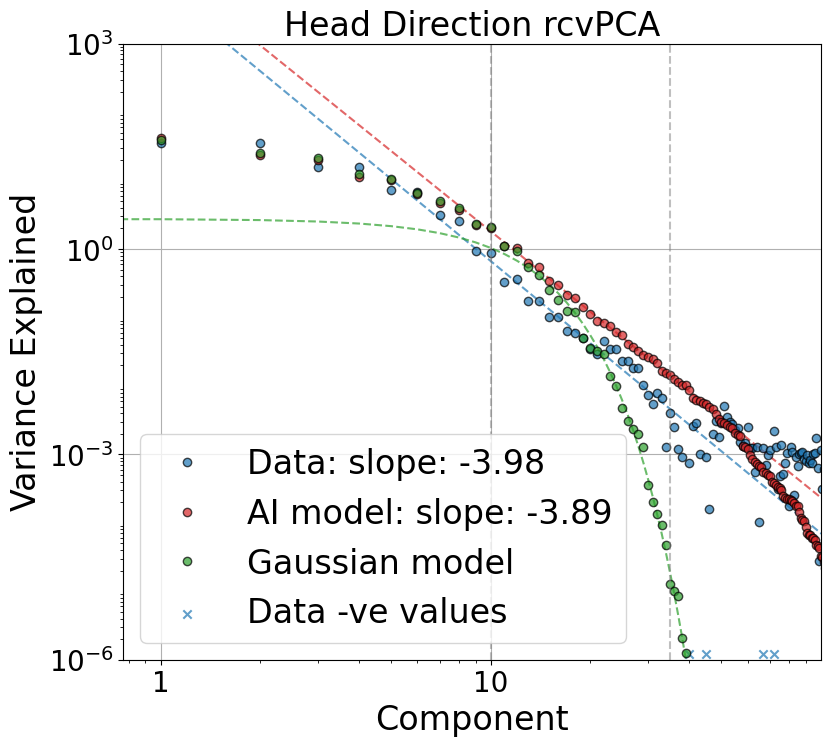

In [70]:
data_evals_scalar = np.sum(evals_est) / np.sum(evals_model)

evals_list = [evals_est / data_evals_scalar, evals_model, evals_gaussian]

labels = ['Data', 'AI model', 'Gaussian model']
fig = plot_evals(evals_list, labels, fit_range=(10, 35), 
        title="Head Direction rcvPCA",
        # title=r'Head Direction cvpca. evecs v from $\tilde{R_1} ^T \tilde{R_1}$, evals: $v^T R_2^T R_3v$, averaged over 3 ways to choose R1, R2, R3', 
        xlim=(0, 100), 
        ylim=(1e-6, 1e3),
        colors=['tab:blue', 'tab:red', 'tab:green'],
        plot_negative_values=(1e-6 + 2e-7)
)